# *A. niger* Infection of *V. vinifera* — Green vs Mature Berry

**Phase 3B:** Compare infection dynamics between green (*pre-véraison*, iMS7199 green)
and mature (*post-véraison*, iMS7199 mature) berry under identical fungal inoculation,
using the same **leakage model**.

**Key biological question:** Does the berry's developmental stage — and the consequent
difference in cytoplasmic metabolic activity — alter the speed, severity and limiting
nutrients of *A. niger* infection?

---
* **Author:** Joana Maia
* **Solver:** Gurobi (Academic Licence)
* **Core libraries:** COBRApy · Pandas · Seaborn · Matplotlib
* **Models:** *iMS7199* (*V. vinifera* mature) × *iJB1325* (*Aspergillus niger*) · *iMS7199* (*V. vinifera* green) × *iJB1325* (*Aspergillus niger*)

---

## 1. Environment Setup
### 1.1 Package Installation

In [1]:
# !pip install cobra
# !pip install gurobipy
# !pip install matplotlib
# !pip install pandas
# !pip install seaborn

### 1.2 Library Imports and Version Audit

In [2]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Numerical / data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# COBRApy and flux analysis tools
import cobra
from cobra import Model, Reaction, Metabolite
from cobra.flux_analysis import (pfba)
from cobra.io import read_sbml_model
import gurobipy

# Version audit
print(f'COBRApy    : {cobra.__version__}')
print(f'Gurobi     : {".".join(str(v) for v in gurobipy.gurobi.version())}')
print(f'Matplotlib : {matplotlib.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Seaborn    : {sns.__version__}')

COBRApy    : 0.31.1
Gurobi     : 13.0.2
Matplotlib : 3.10.8
NumPy      : 2.4.4
Pandas     : 2.3.3
Seaborn    : 0.13.2


### 1.3 Global Plotting Style

In [3]:
sns.set_theme(style = 'whitegrid', context = 'notebook', font_scale = 1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

C_GREEN   = '#2D6A4F'  # green berry
C_MATURE  = '#E76F51'  # mature berry

GAS_NAMES = {'O2', 'CO2', 'Water'}

### 1.4 Model Loading

Loads the curated models from Phase 1A (`An_curated.xml`, *iJB1325*), Phase 1B (`VvM_mature_curated.xml`, *iMS7199*) and Phase 1C (`VvG_green_curated.xml`, *iMS7199*)

In [4]:
GREEN_PATH  = 'VvG_green_curated.xml'
MATURE_PATH = 'VvM_mature_curated.xml'
FUNGUS_PATH = 'An_curated.xml'

for p in [GREEN_PATH, MATURE_PATH, FUNGUS_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'{p} not found. Run Phase 1 notebooks first.')

vv_green  = read_sbml_model(GREEN_PATH)
vv_mature = read_sbml_model(MATURE_PATH)
an_raw    = read_sbml_model(FUNGUS_PATH)

sol_green  = vv_green.optimize()
sol_mature = vv_mature.optimize()
sol_an     = an_raw.optimize()

print(f'V. vinifera green  : {len(vv_green.reactions):>5} rxns, {len(vv_green.metabolites):>5} mets — μ = {sol_green.objective_value:.4f} h⁻¹')
print(f'V. vinifera mature : {len(vv_mature.reactions):>5} rxns, {len(vv_mature.metabolites):>5} mets — μ = {sol_mature.objective_value:.4f} h⁻¹')
print(f'A. niger           : {len(an_raw.reactions):>5} rxns, {len(an_raw.metabolites):>5} mets — μ = {sol_an.objective_value:.4f} h⁻¹')
print(f'\nΔμ (mature − green): {sol_mature.objective_value - sol_green.objective_value:.4f} h⁻¹')

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2747228
Academic license 2747228 - for non-commercial use only - registered to pg___@uminho.pt


'' is not a valid SBML 'SId'.


V. vinifera green  :  4495 rxns,  4399 mets — μ = 0.1446 h⁻¹
V. vinifera mature :  4272 rxns,  5143 mets — μ = 0.1541 h⁻¹
A. niger           :  2320 rxns,  1818 mets — μ = 0.9399 h⁻¹

Δμ (mature − green): 0.0095 h⁻¹


## 2. Interface Metabolite Definition

The same 19 interface metabolites are used. All IDs are verified against both grape models — green and mature.

In [5]:
# Exact IDs — verified in Phase 1C (both models)
INTERFACE_EXACT = {
    'Glucose'  :{'vv_id':'GLC__cyto',            'an_id':'GLCe',  'cat':'C-source'},
    'Fructose' :{'vv_id':'Fructofuranose__cyto',  'an_id':'FRUe',  'cat':'C-source'},
    'Malate'   :{'vv_id':'MAL__cyto',             'an_id':'MALe',  'cat':'Organic acid'},
    'Fumarate' :{'vv_id':'FUM__cyto',             'an_id':'FUMe',  'cat':'Organic acid'},
    'Citrate'  :{'vv_id':'CIT__cyto',             'an_id':'CITe',  'cat':'Organic acid'},
    'Succinate':{'vv_id':'SUC__cyto',             'an_id':'SUCCe', 'cat':'Organic acid'},
    'Proline'  :{'vv_id':'PRO__cyto',             'an_id':'PROe',  'cat':'Amino acid'},
    'Leucine'  :{'vv_id':'LEU__cyto',             'an_id':'LEUe',  'cat':'Amino acid'},
    'Serine'   :{'vv_id':'SER__cyto',             'an_id':'SERe',  'cat':'Amino acid'},
    'Glutamate':{'vv_id':'GLT__cyto',             'an_id':'GLUe',  'cat':'Amino acid'},
    'Alanine'  :{'vv_id':'L-ALPHA-ALANINE__cyto', 'an_id':'ALAe',  'cat':'Amino acid'},
    'Glycine'  :{'vv_id':'GLY__cyto',             'an_id':'GLYe',  'cat':'Amino acid'},
    'Nitrate'  :{'vv_id':'NITRATE__cyto',         'an_id':'HNO3e', 'cat':'Inorganic'},
    'Phosphate':{'vv_id':'Pi__cyto',              'an_id':'PIe',   'cat':'Inorganic'},
    'Sulfate'  :{'vv_id':'SULFATE__cyto',         'an_id':'SLFe',  'cat':'Inorganic'},
    'Adenine'  :{'vv_id':'ADENINE__cyto',         'an_id':'ADe',   'cat':'Nucleobase'},
    'O2'       :{'vv_id':'OXYGEN-MOLECULE__cyto', 'an_id':'O2e',   'cat':'Gas'},
    'CO2'      :{'vv_id':'CARBON-DIOXIDE__cyto',  'an_id':'CO2e',  'cat':'Gas'},
    'Water'    :{'vv_id':'WATER__cyto',           'an_id':'H2Oe',  'cat':'Water'},}

# Verify in both models
green_met_ids  = {m.id for m in vv_green.metabolites}
mature_met_ids = {m.id for m in vv_mature.metabolites}
an_met_ids     = {m.id for m in an_raw.metabolites}

print(f'{"Metabolite":<14} {"Green":>8} {"Mature":>8} {"Fungus":>8}')
print('_' * 44)
all_ok = True
for name, ids in INTERFACE_EXACT.items():
    g = 'ok' if ids['vv_id'] in green_met_ids  else '(!)'
    m = 'ok' if ids['vv_id'] in mature_met_ids else '(!)'
    a = 'ok' if ids['an_id'] in an_met_ids     else '(!)'
    if '(!)' in [g, m, a]: all_ok = False
    print(f'{name:<14} {g:>8} {m:>8} {a:>8}')

print(f'\n{"All verified" if all_ok else "WARNING: missing IDs"}')
INTERFACE_MAP = {n: ids for n, ids in INTERFACE_EXACT.items()}

Metabolite        Green   Mature   Fungus
____________________________________________
Glucose              ok       ok       ok
Fructose             ok       ok       ok
Malate               ok       ok       ok
Fumarate             ok       ok       ok
Citrate              ok       ok       ok
Succinate            ok       ok       ok
Proline              ok       ok       ok
Leucine              ok       ok       ok
Serine               ok       ok       ok
Glutamate            ok       ok       ok
Alanine              ok       ok       ok
Glycine              ok       ok       ok
Nitrate              ok       ok       ok
Phosphate            ok       ok       ok
Sulfate              ok       ok       ok
Adenine              ok       ok       ok
O2                   ok       ok       ok
CO2                  ok       ok       ok
Water                ok       ok       ok

All verified


## 3. Community Model Construction

Two community models are built with identical architecture:
- **community_green**: iMS7199 green × iJB1325
- **community_mature**: iMS7199 mature × iJB1325

Each community model couples one berry GEM to *iJB1325* via an explicit **infection interface compartment** (`inf`), through which nutrients flow unidirectionally from host to pathogen:

```
[berry cytosol] ──T1──► [infection compartment] ──T2──► [fungus extracellular]
```

- **T1** (berry cytosol → interface, $lb = 0$, $ub = 1000$): represents cytoplasmic leakage driven by fungal cell-wall degradation. T1 is unconstrained structurally; flux is regulated indirectly via T2 bounds.
- **T2** (interface → fungal extracellular, $lb = 0$, $ub = 1000$): represents nutrient uptake by the fungus. T2 upper bounds are set by the leakage formula at each timestep, enforcing the supply limit.
- **Direct fungal boundary reactions** (`an_BOUNDARY_*`) with negative lower bounds are blocked ($lb = 0$), forcing *A. niger* to obtain all nutrients exclusively through the T1→T2 interface — simulating infection-dependent nutrient acquisition.

Both communities share the same *iJB1325* instance (prefixed `an_`) and
differ only in the berry sub-model: `vvg_*` (green) or `vvm_*` (mature).

In [6]:
def prefix_model(model_original, prefix):
    m = model_original.copy()
    m.id = prefix
    for met in m.metabolites:
        met.id = f'{prefix}_{met.id}'
        if met.compartment:
            met.compartment = f'{prefix}_{met.compartment}'
    m.compartments = {f'{prefix}_{k}': v for k, v in m.compartments.items()}
    for rxn in m.reactions:
        rxn.id = f'{prefix}_{rxn.id}'
    for gene in m.genes:
        gene.id = f'{prefix}_{gene.id}'
    return m

def build_community(vv_model, an_model, vv_prefix, label):
    vv = prefix_model(vv_model, vv_prefix)
    an = prefix_model(an_model, 'an')
    
    community = Model(f'community_{label}')
    community.solver = 'gurobi'
    for rxn in vv.reactions: community.add_reactions([rxn.copy()])
    for rxn in an.reactions: community.add_reactions([rxn.copy()])
    community.compartments['inf'] = 'infection_interface'
    
    T1_reactions, T2_reactions = [], []
    
    for name, ids in INTERFACE_MAP.items():
        vv_cyto_full = f'{vv_prefix}_{ids["vv_id"]}'
        an_extr_full = f'an_{ids["an_id"]}'
        inf_id       = f'inf_{name}'
        
        if inf_id not in {m.id for m in community.metabolites}:
            inf_met = Metabolite(inf_id, name = f'{name} (infection)', compartment = 'inf')
        else:
            inf_met = community.metabolites.get_by_id(inf_id)
        
        # T1: vv_cytosol → inf (unidirectional)
        t1 = Reaction(f'T1_{name}', lower_bound = 0, upper_bound = 1000, subsystem = 'T1_transport')
        try:
            vv_met = community.metabolites.get_by_id(vv_cyto_full)
            t1.add_metabolites({vv_met: -1, inf_met: 1})
            community.add_reactions([t1]); T1_reactions.append(f'T1_{name}')
        except KeyError: continue
        
        # T2: inf → an_extracellular (unidirectional)
        t2 = Reaction(f'T2_{name}', lower_bound = 0, upper_bound = 1000, subsystem = 'T2_transport')
        try:
            an_met = community.metabolites.get_by_id(an_extr_full)
            t2.add_metabolites({inf_met: -1, an_met: 1})
            community.add_reactions([t2]); T2_reactions.append(f'T2_{name}')
        except KeyError: pass
    
    # Block direct fungal uptakes
    blocked = 0
    for rxn in community.reactions:
        if rxn.id.startswith('an_BOUNDARY_') and rxn.lower_bound < 0:
            rxn.lower_bound = 0; blocked += 1
    
    # IDs
    vv_biomass_id = [r.id for r in community.reactions
                     if 'biomass' in r.id.lower() and 'drain' not in r.id.lower()
                     and r.id.startswith(vv_prefix)][0]
    an_growth_id  = [r.id for r in community.reactions if 'GROWTH' in r.id][0]
    
    print(f'{label}: {len(community.reactions)} rxns | T1 = {len(T1_reactions)} T2 = {len(T2_reactions)} | blocked = {blocked}')
    return community, T1_reactions, T2_reactions, vv_biomass_id, an_growth_id

comm_g, T1_g, T2_g, vv_bio_g, an_gro_g = build_community(vv_green,  an_raw, 'vvg', 'green')
comm_m, T1_m, T2_m, vv_bio_m, an_gro_m = build_community(vv_mature, an_raw, 'vvm', 'mature')

Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmpiyyq70_x.lp
Reading time = 0.03 seconds
: 4399 rows, 8990 columns, 38116 nonzeros
Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmpt7zisv_3.lp
Reading time = 0.00 seconds
: 1818 rows, 4640 columns, 16506 nonzeros
green: 6853 rxns | T1 = 19 T2 = 19 | blocked = 8
Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmpjix37ei2.lp
Reading time = 0.01 seconds
: 5143 rows, 8544 columns, 35884 nonzeros
Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmpsd19byqn.lp
Reading time = 0.00 seconds
: 1818 rows, 4640 columns, 16506 nonzeros
mature: 6630 rxns | T1 = 19 T2 = 19 | blocked = 8


## 4. Cytoplasmic Flux Proxies — Green vs Mature

The leakage proxy is computed separately for each berry stage from its own pFBA:

```
cyto_flux_proxy[met] = Σ |flux(rxn)| for reactions consuming met in cytosol (grape pFBA at full metabolic capacity)
```

**Key insight:** Different developmental stages have different cytoplasmic metabolic activity → different leakage potential → different infection dynamics.

### Results

The two developmental stages show markedly different leakage profiles,
both in magnitude and composition.

**Green berry** (*pre-véraison*): the proxy is dominated by **Glutamate** ($18.15\, mmol/gDW/h$) and **Proline** ($7.98\, mmol/gDW/h$). High glutamate turnover reflects active nitrogen metabolism and amino acid biosynthesis in mitotically active tissue; elevated proline is consistent with its dual role as an osmoprotectant and nitrogen store characteristic of *pre-véraison* berries.

**Mature berry** (*post-véraison*): the proxy is dominated by **Citrate** ($19.37\, mmol/gDW/h$) and **Phosphate** ($13.34\, mmol/gDW/h$). High citrate turnover reflects the intense TCA activity associated with organic acid accumulation at ripening; elevated phosphate reflects high ATP turnover in a cell maintaining active sugar loading.

**Glucose and fructose proxies are zero in both stages** — free hexoses are not actively turned over in the cytosol under the model's carbon source constraints (sucrose is the primary carbon input; hexose pools are vacuolar).

The mature berry's higher total proxy predicts greater overall nutrient availability at the infection interface — implying more permissive conditions for *A. niger* establishment relative to the green berry.

In [7]:
def compute_proxy(community, vv_prefix, vv_biomass_id, T1_reactions, label):
    with community:
        community.objective = {community.reactions.get_by_id(vv_biomass_id): 1}
        sol = pfba(community)
    
    proxy = {}
    for name in INTERFACE_MAP:
        vv_cyto_id = f'{vv_prefix}_{INTERFACE_MAP[name]["vv_id"]}'
        try:
            met   = community.metabolites.get_by_id(vv_cyto_id)
            total = sum(
                abs(sol.fluxes.get(rxn.id, 0))
                for rxn in met.reactions
                if rxn.metabolites.get(met, 0) < 0
                and rxn.id.startswith(f'{vv_prefix}_')
            )
            proxy[name] = total
        except KeyError:
            proxy[name] = 0.0
    
    return proxy

proxy_g = compute_proxy(comm_g, 'vvg', vv_bio_g, T1_g, 'green')
proxy_m = compute_proxy(comm_m, 'vvm', vv_bio_m, T1_m, 'mature')

print(f'{"Metabolite":<14} {"Green proxy":>14} {"Mature proxy":>14} {"Ratio G/M":>12}')
print('_' * 58)
for name in sorted(proxy_m, key=lambda x: proxy_m[x], reverse = True):
    if name not in GAS_NAMES:
        g = proxy_g.get(name, 0)
        m = proxy_m.get(name, 0)
        ratio = f'{g/m:.2f}' if m > 0 else 'N/A'
        flag = ' ←' if g != m else ''
        print(f'{name:<14} {g:>14.4f} {m:>14.4f} {ratio:>12}{flag}')

Metabolite        Green proxy   Mature proxy    Ratio G/M
__________________________________________________________
Citrate                1.2037        19.3676         0.06 ←
Phosphate              2.0329        13.3408         0.15 ←
Glycine                0.5607         2.5920         0.22 ←
Alanine                0.0932         1.9469         0.05 ←
Glutamate             18.1477         1.5387        11.79 ←
Nitrate                0.7903         1.4644         0.54 ←
Serine                 0.0627         1.2802         0.05 ←
Malate                 1.6300         0.1876         8.69 ←
Leucine                0.0981         0.1460         0.67 ←
Fumarate               0.0515         0.0754         0.68 ←
Proline                7.9764         0.0701       113.78 ←
Succinate              0.0388         0.0462         0.84 ←
Sulfate                0.0111         0.0161         0.69 ←
Adenine                0.0219         0.0115         1.92 ←
Glucose                0.0000         0.000

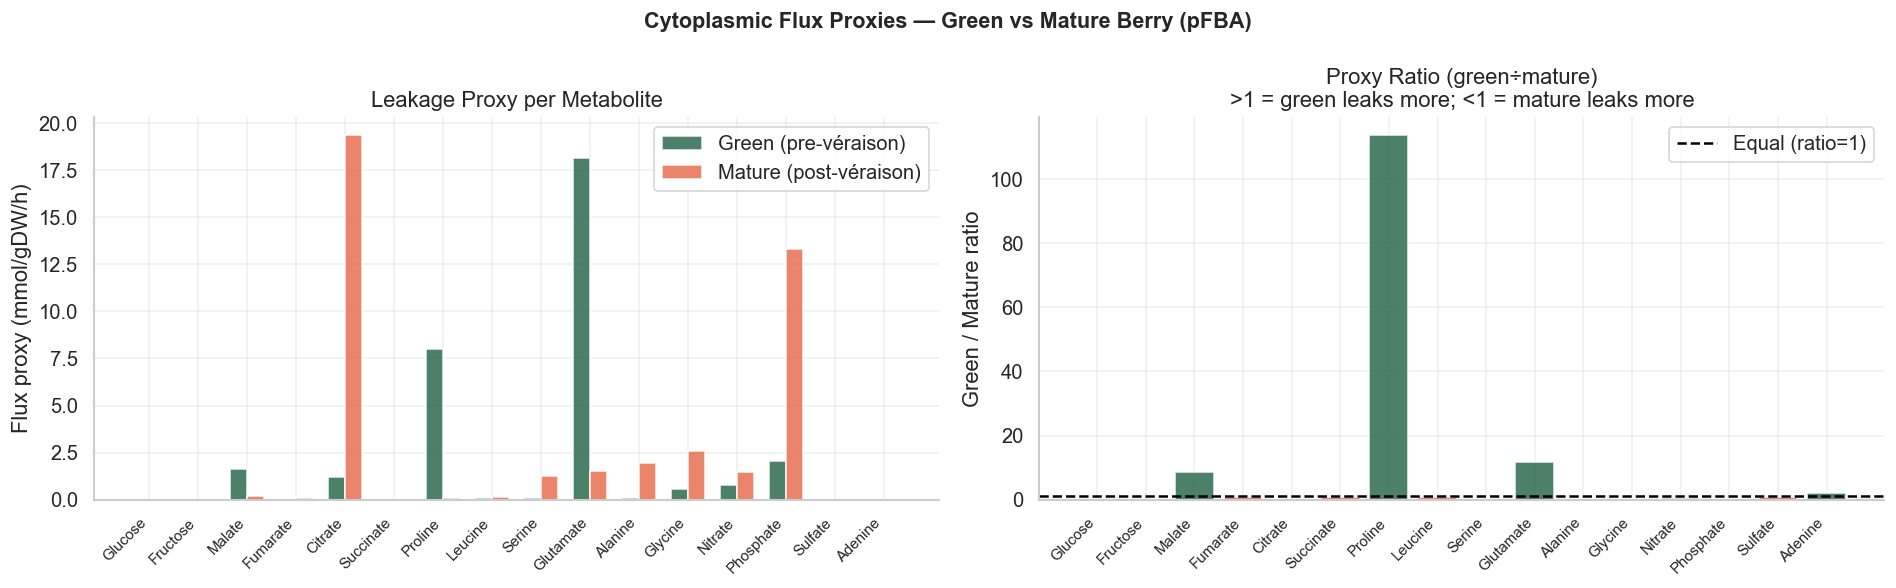

In [8]:
non_gas = [n for n in INTERFACE_MAP if n not in GAS_NAMES]
x  = np.arange(len(non_gas)); w = 0.35

vals_g = [proxy_g.get(n, 0) for n in non_gas]
vals_m = [proxy_m.get(n, 0) for n in non_gas]

fig, axes = plt.subplots(1, 2, figsize = (16, 5))
fig.suptitle('Cytoplasmic Flux Proxies — Green vs Mature Berry (pFBA)', fontsize = 13, fontweight = 'bold')

axes[0].bar(x-w/2, vals_g, w, color = C_GREEN,  alpha = 0.85, label = 'Green (pre-véraison)')
axes[0].bar(x+w/2, vals_m, w, color = C_MATURE, alpha = 0.85, label = 'Mature (post-véraison)')
axes[0].set_xticks(x); axes[0].set_xticklabels(non_gas, rotation = 45, ha = 'right', fontsize = 9)
axes[0].set_ylabel('Flux proxy (mmol/gDW/h)')
axes[0].set_title('Leakage Proxy per Metabolite')
axes[0].legend(); axes[0].grid(alpha = 0.3)

# Ratio plot
ratios = [proxy_g.get(n,0)/proxy_m.get(n,1e-9) if proxy_m.get(n,0) > 0 else 0 for n in non_gas]
bar_colors = [C_GREEN if r > 1 else C_MATURE for r in ratios]
axes[1].bar(non_gas, ratios, color = bar_colors, alpha = 0.85, edgecolor = 'white')
axes[1].axhline(1.0, color = 'black', lw = 1.5, ls = '--', label = 'Equal (ratio=1)')
axes[1].set_xticks(range(len(non_gas))); axes[1].set_xticklabels(non_gas, rotation = 45, ha = 'right', fontsize = 9)
axes[1].set_ylabel('Green / Mature ratio')
axes[1].set_title('Proxy Ratio (green÷mature)\n>1 = green leaks more; <1 = mature leaks more')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('fig1_proxy_comparison.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 5. Infection Intensity Scan — Green vs Mature

Steady-state scan of infection intensity (`f_infection` $0.0 → 1.0$, $0.05$) for both berry stages. At each step, **T2 upper bounds** are
set from the leakage formula:

```
T2_ub[met] = f_infection × proxy[met]
```

limiting the flow of each metabolite from the infection interface into the fungal extracellular space. T1 reactions (berry cytosol → interface) remain unconstrained ($ub = 1000$). Berry and fungus FBAs are solved sequentially — not as a joint community optimisation.

At full infection (`f_{infection}` = $1.0$), *A. niger* reaches $\mu = 0.1724\, h^{-1}$ on the green berry and $\mu = 0.1703\, h^{-1}$ on the mature berry — a difference of only $1.2\%$. Both stages support near-identical maximum fungal growth rates at saturation, confirming that the limiting factor at high infection intensity is internal to the fungal network (likely O₂ or cofactor constraints), not the quantity of nutrients leaked.

Panel 3 reveals a smooth, continuous trade-off between host and pathogen growth in both stages — no binary switching. The crossover point ($\mu_{an} = \mu_{vv}$) and the saturation threshold differ between stages, reflecting the different T2 leakage profiles: the mature berry, with its higher total proxy ($42.08$ vs $32.72\, mmol/gDW/h$), reaches fungal saturation at a lower `f_{infection}`.

**Gas handling:** O₂, CO₂ and H₂O are excluded from the T2 leakage formula. O₂ is supplied atmospherically; CO₂ and H₂O are fungal metabolic products.

In [9]:
def inf_scan(community, 
                     vv_biomass_id, 
                     an_growth_id, 
                     T1_reactions, 
                     T2_reactions,
                     proxy, 
                     vv_prefix, 
                     label):
    with community:
        community.objective = {community.reactions.get_by_id(vv_biomass_id): 1}
        vv_mu_max = community.optimize().objective_value

    results = []
    for f_inf in np.arange(0.0, 1.01, 0.05):
        f_inf   = round(float(f_inf), 2)
        f_host  = max(0.0, 1.0 - f_inf)
        T1_act  = {f'T1_{n}': max(0.0, proxy.get(n,0) * f_inf)
                   for n in INTERFACE_MAP if n not in GAS_NAMES}

        with community:
            community.reactions.get_by_id(vv_biomass_id).upper_bound = max(0.0, f_host * vv_mu_max)
            community.objective = {community.reactions.get_by_id(vv_biomass_id): 1}
            sol_vv = community.optimize()
            vv_mu  = sol_vv.objective_value if sol_vv.status == 'optimal' else 0

        with community:
            for t1_id, flux in T1_act.items():
                t2_id = t1_id.replace('T1_', 'T2_')
                try:
                    t2r = community.reactions.get_by_id(t2_id)
                    if t2r.lower_bound >= 0: t2r.upper_bound = max(0.0, flux)
                except KeyError: pass
            community.objective = {community.reactions.get_by_id(an_growth_id): 1}
            sol_an = community.optimize()
            an_mu  = sol_an.objective_value if sol_an.status == 'optimal' else 0

        results.append({'f_infection': f_inf,
                        'f_host':f_host,
                        'vv_mu':round(vv_mu,4),
                        'an_mu':round(an_mu,4),
                        'T1_total':round(sum(T1_act.values()),4),
                        'stage':label})
    return pd.DataFrame(results)

print('Infection Intensity Scan — green berry...')
df_scan_g = inf_scan(comm_g, vv_bio_g, an_gro_g, T1_g, T2_g, proxy_g, 'vvg', 'green')
print('Infection Intensity Scan — mature berry...')
df_scan_m = inf_scan(comm_m, vv_bio_m, an_gro_m, T1_m, T2_m, proxy_m, 'vvm', 'mature')

df_scan = pd.concat([df_scan_g, df_scan_m], ignore_index=True)
print('\nDone.')
print(f'Green  at f_inf = 1.0: an μ = {df_scan_g.iloc[-1]["an_mu"]:.4f} h⁻¹')
print(f'Mature at f_inf = 1.0: an μ = {df_scan_m.iloc[-1]["an_mu"]:.4f} h⁻¹')

Infection Intensity Scan — green berry...
Infection Intensity Scan — mature berry...

Done.
Green  at f_inf = 1.0: an μ = 0.1724 h⁻¹
Mature at f_inf = 1.0: an μ = 0.1703 h⁻¹


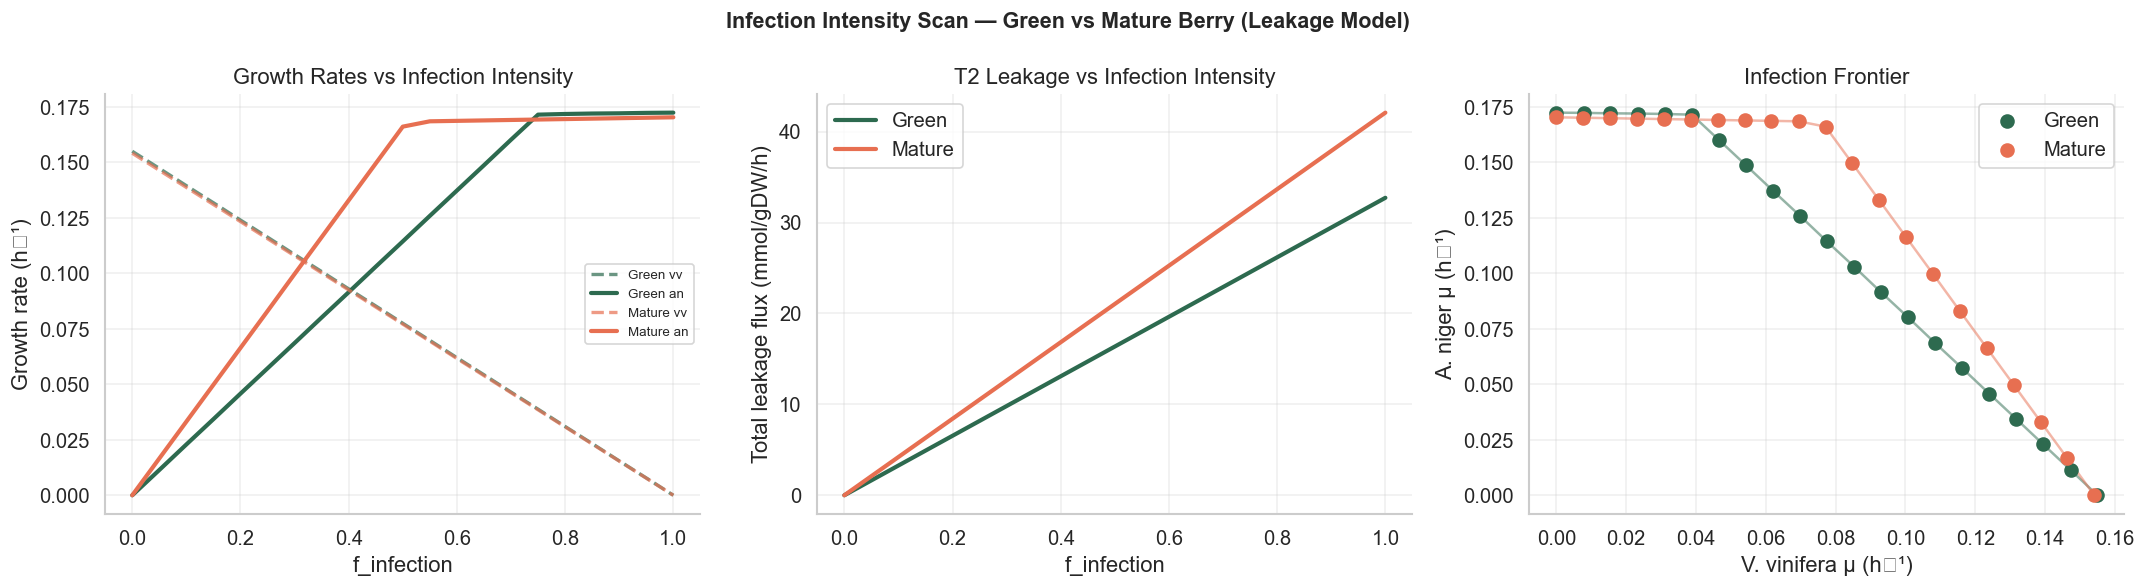

In [10]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))
fig.suptitle('Infection Intensity Scan — Green vs Mature Berry (Leakage Model)', fontsize = 13, fontweight = 'bold')

for df_s, color, label in [(df_scan_g, C_GREEN, 'Green'), (df_scan_m, C_MATURE, 'Mature')]:
    axes[0].plot(df_s['f_infection'], df_s['vv_mu'], color = color, lw = 2, ls = '--', alpha = 0.7, label = f'{label} vv')
    axes[0].plot(df_s['f_infection'], df_s['an_mu'], color = color, lw = 2.5, label = f'{label} an')
axes[0].set_xlabel('f_infection'); axes[0].set_ylabel('Growth rate (h⁻¹)')
axes[0].set_title('Growth Rates vs Infection Intensity'); axes[0].legend(fontsize = 8); axes[0].grid(alpha = 0.3)

for df_s, color, label in [(df_scan_g, C_GREEN, 'Green'), (df_scan_m, C_MATURE, 'Mature')]:
    axes[1].plot(df_s['f_infection'], df_s['T1_total'], color = color, lw = 2.5, label = label)
axes[1].set_xlabel('f_infection'); axes[1].set_ylabel('Total leakage flux (mmol/gDW/h)')
axes[1].set_title('T2 Leakage vs Infection Intensity'); axes[1].legend(); axes[1].grid(alpha = 0.3)

for df_s, color, label in [(df_scan_g, C_GREEN, 'Green'), (df_scan_m, C_MATURE, 'Mature')]:
    sc = axes[2].scatter(df_s['vv_mu'], df_s['an_mu'], color = color, s = 60, label = label, zorder = 3)
    axes[2].plot(df_s['vv_mu'], df_s['an_mu'], color = color, lw = 1.5, alpha = 0.5)
axes[2].set_xlabel('V. vinifera μ (h⁻¹)'); axes[2].set_ylabel('A. niger μ (h⁻¹)')
axes[2].set_title('Infection Frontier'); axes[2].legend(); axes[2].grid(alpha = 0.3)

plt.tight_layout()
# plt.savefig('fig2_infscan_green_vs_mature.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 6. dFBA — Infection Progression: Green vs Mature

Dynamic FBA simulates the time evolution of infection using the leakage model. At each timestep $dt$:

1. `f_{infection}` = $\dfrac{bm_{an}}{bm_{an} + K_{half}}$

2. `f_{host} = 1 - f_{infection}`

3. T2 bounds are set: `T2_{ub}[met] = f_{infection} × proxy[met]``

4. Berry FBA: $\mu_{vv}$ computed with upper bound `f_{host}` $\times
   \mu_{max}^{vv}$
5. Fungus FBA: $\mu_{an}$ computed with T2 bounds
6. Biomass update: $bm_{an} \mathrel{+}= \mu_{an} \times bm_{an} \times dt$
   (capped at `K_{fungus}`); $bm_{vv}$ held constant

**Parameters:** $dt = 0.5\, h$, $t_{end} = 120\, h$,
$K_{fungus} = 50\, gDW/L$, $K_{half} = 0.01\, gDW/L$,
$bm_{vv,0} = 1.0\, gDW/L$, $bm_{an,0} = 0.001\, gDW/L$

Both infections reach the fungal carrying capacity (`K_{fungus}` = $50\, gDW/L$), but at different speeds:

The mature berry is colonised **$16\, h$ faster** than the green berry (a $15.5\%$ reduction in time to peak), driven by its higher total leakage proxy. Despite the green berry producing more glutamate and proline at the interface, the mature berry's dominant metabolites — citrate and phosphate — provide the carbon backbone and phosphorus supply needed for rapid early fungal establishment.

The `f_{infection}` = $0.95$ threshold is reached at $t = 54\, h$ in the
mature berry versus $t = 70\, h$ in the green berry, meaning the host's metabolic capacity is effectively overwhelmed $16\, h$ earlier at maturation — a window with direct relevance to post-harvest infection timing.



In [11]:
def run_dfba(community, 
             vv_biomass_id, 
             an_growth_id,
             T1_reactions, 
             T2_reactions, 
             proxy,
             biomass_vv_0 = 1.0, 
             biomass_an_0 = 0.001,
             dt           = 0.5, 
             t_end        = 120.0, 
             K_fungus     = 50.0, 
             half_sat     = 0.01,
             f_host_fixed = None, 
             label        = ''):
    """
    Leakage model dFBA.
    """
    with community:
        community.objective = {community.reactions.get_by_id(vv_biomass_id): 1}
        _vv_mu_max = community.optimize().objective_value

    rxn_vv  = community.reactions.get_by_id(vv_biomass_id)
    rxn_an  = community.reactions.get_by_id(an_growth_id)
    bm_vv   = biomass_vv_0
    bm_an   = biomass_an_0
    results = []

    rxn_vv.lower_bound = 0.0; rxn_vv.upper_bound = 1000.0
    rxn_an.lower_bound = 0.0; rxn_an.upper_bound = 1000.0

    try:
        for t in np.arange(0, t_end, dt):
            if f_host_fixed is not None:
                f_host = f_host_fixed; f_inf = 1.0 - f_host
            else:
                f_inf  = bm_an / (bm_an + half_sat)
                f_host = 1.0 - f_inf

            T1_act = {f'T1_{n}': max(0.0, proxy.get(n, 0) * f_inf)
                      for n in INTERFACE_MAP if n not in GAS_NAMES}

            with community:
                rxn_vv.upper_bound = max(0.0, f_host * _vv_mu_max)
                community.objective = {rxn_vv: 1}
                sol_vv    = community.optimize()
                vv_growth = sol_vv.objective_value if sol_vv.status == 'optimal' else 0

            with community:
                for t1_id, flux in T1_act.items():
                    t2_id = t1_id.replace('T1_', 'T2_')
                    try:
                        t2r = community.reactions.get_by_id(t2_id)
                        if t2r.lower_bound >= 0: t2r.upper_bound = max(0.0, flux)
                    except KeyError: pass
                community.objective = {rxn_an: 1}
                sol_an    = community.optimize()
                an_growth = sol_an.objective_value if sol_an.status == 'optimal' else 0

            bm_an = min(bm_an + an_growth * bm_an * dt, K_fungus)

            row = {'time_h'      : round(t, 2),
                   'biomass_vv'  : round(bm_vv, 5),
                   'biomass_an'  : round(bm_an, 5),
                   'f_host'      : round(f_host, 4),
                   'f_infection' : round(f_inf, 4),
                   'vv_growth'   : round(vv_growth, 5),
                   'an_growth'   : round(an_growth, 5),
                   'T1_total'    : round(sum(T1_act.values()), 4),}
            for t1_id in T1_reactions:
                row[f'flux_{t1_id}'] = round(T1_act.get(t1_id, 0), 5)
            results.append(row)

    finally:
        rxn_vv.lower_bound = 0.0; rxn_vv.upper_bound = 1000.0
        rxn_an.lower_bound = 0.0; rxn_an.upper_bound = 1000.0

    return pd.DataFrame(results)

print('Running dFBA — green berry')
df_g = run_dfba(comm_g, vv_bio_g, an_gro_g, T1_g, T2_g, proxy_g, dt=0.5, t_end=120.0, label='[green]')
print(f'    Peak: {df_g["biomass_an"].max():.3f} gDW/L at t={df_g.loc[df_g["biomass_an"].idxmax(),"time_h"]:.0f}h')

print('Running dFBA — mature berry')
df_m = run_dfba(comm_m, vv_bio_m, an_gro_m, T1_m, T2_m, proxy_m, dt=0.5, t_end=120.0, label='[mature]')
print(f'    Peak: {df_m["biomass_an"].max():.3f} gDW/L at t={df_m.loc[df_m["biomass_an"].idxmax(),"time_h"]:.0f}h')

Running dFBA — green berry
    Peak: 50.000 gDW/L at t=103h
Running dFBA — mature berry
    Peak: 50.000 gDW/L at t=87h


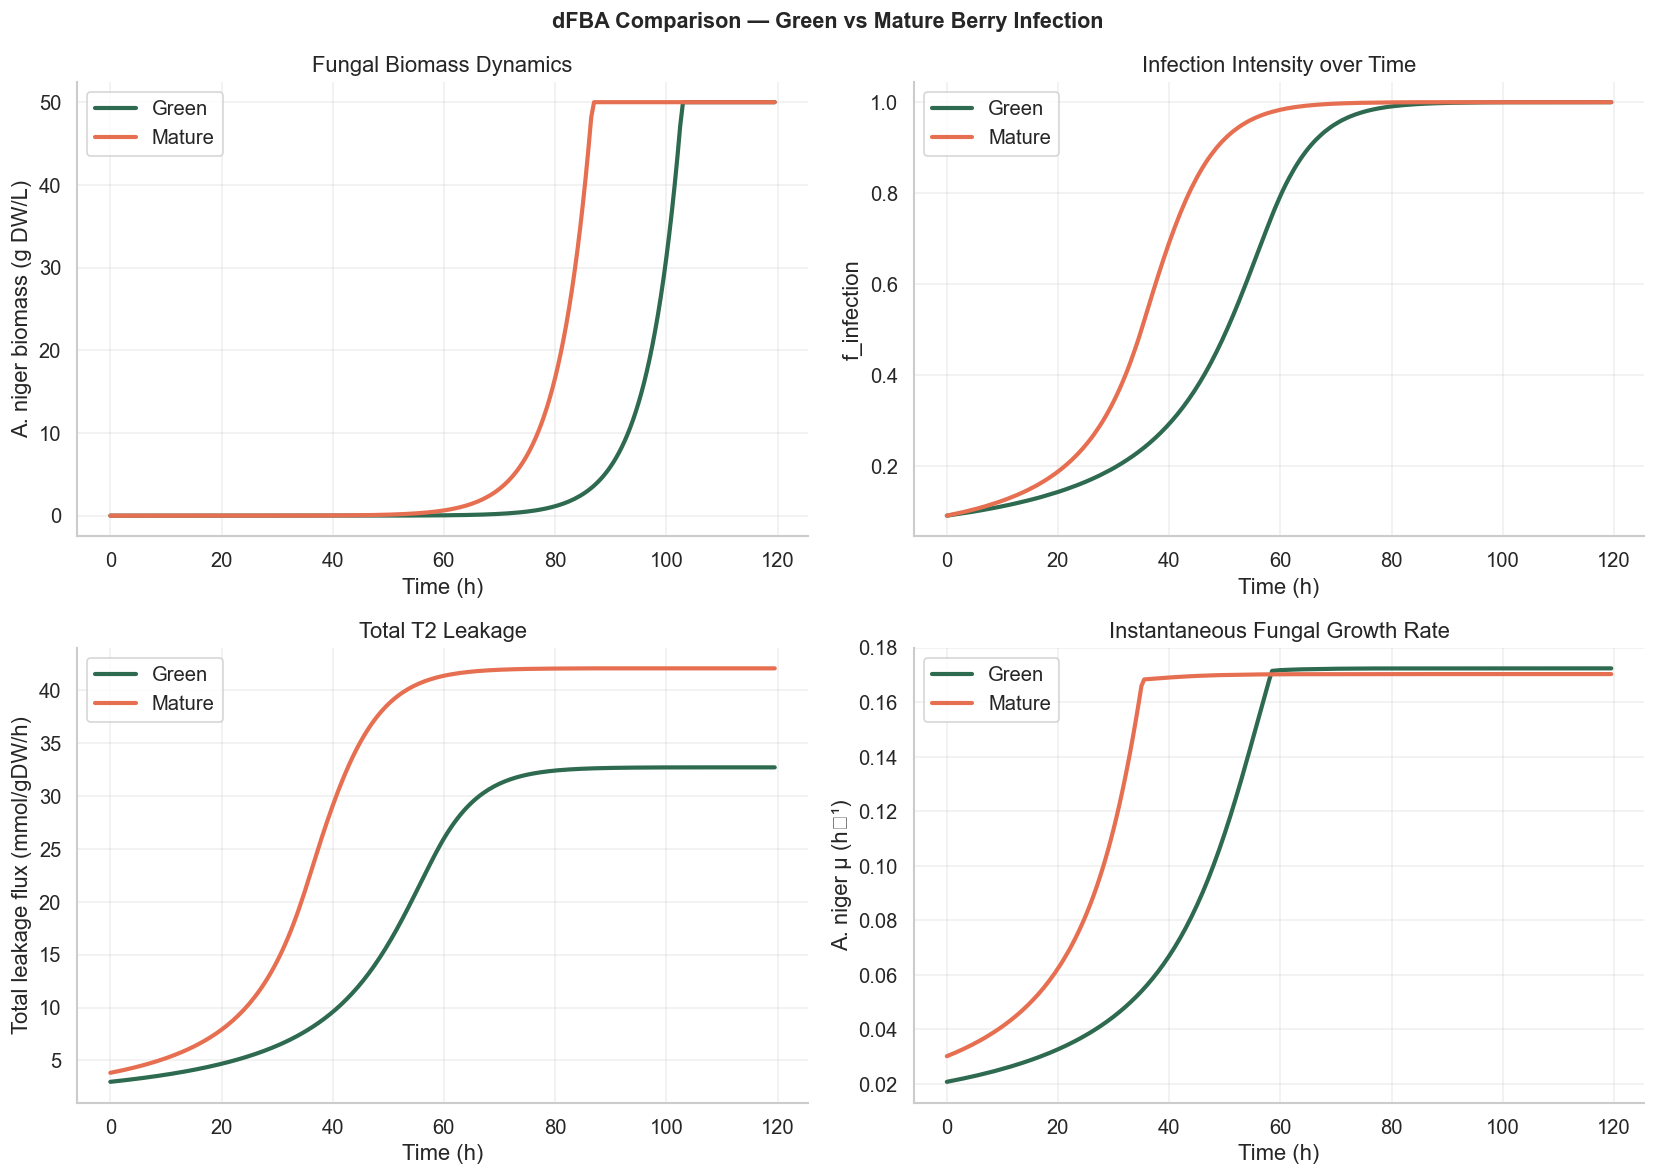

In [12]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
fig.suptitle('dFBA Comparison — Green vs Mature Berry Infection', fontsize = 13, fontweight = 'bold')

for df_s, color, label in [(df_g, C_GREEN, 'Green'), (df_m, C_MATURE, 'Mature')]:
    axes[0,0].plot(df_s['time_h'], df_s['biomass_an'], color = color, lw = 2.5, label = label)
axes[0,0].set_ylabel('A. niger biomass (g DW/L)'); axes[0,0].set_xlabel('Time (h)')
axes[0,0].set_title('Fungal Biomass Dynamics'); axes[0,0].legend(); axes[0,0].grid(alpha = 0.3)

for df_s, color, label in [(df_g, C_GREEN, 'Green'), (df_m, C_MATURE, 'Mature')]:
    axes[0,1].plot(df_s['time_h'], df_s['f_infection'], color = color, lw = 2.5, label = label)
axes[0,1].set_ylabel('f_infection'); axes[0,1].set_xlabel('Time (h)')
axes[0,1].set_title('Infection Intensity over Time'); axes[0,1].legend(); axes[0,1].grid(alpha = 0.3)

for df_s, color, label in [(df_g, C_GREEN, 'Green'), (df_m, C_MATURE, 'Mature')]:
    axes[1,0].plot(df_s['time_h'], df_s['T1_total'], color = color, lw = 2.5, label = label)
axes[1,0].set_ylabel('Total leakage flux (mmol/gDW/h)'); axes[1,0].set_xlabel('Time (h)')
axes[1,0].set_title('Total T2 Leakage'); axes[1,0].legend(); axes[1,0].grid(alpha = 0.3)

for df_s, color, label in [(df_g, C_GREEN, 'Green'), (df_m, C_MATURE, 'Mature')]:
    axes[1,1].plot(df_s['time_h'], df_s['an_growth'], color = color, lw = 2.5, label = label)
axes[1,1].set_ylabel('A. niger μ (h⁻¹)'); axes[1,1].set_xlabel('Time (h)')
axes[1,1].set_title('Instantaneous Fungal Growth Rate'); axes[1,1].legend(); axes[1,1].grid(alpha = 0.3)

plt.tight_layout()
# plt.savefig('fig3_dfba_green_vs_mature.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 7. Key Results Comparison

Summary of infection dynamics across both berry stages.

### Interpretation

The key result is unambiguous: **the mature berry is more susceptible** to *A. niger* infection than the green berry under the leakage model. The higher total cytoplasmic flux proxy of the mature stage ($42.08$ vs $32.72\, mmol/gDW/h$, $+28.6\%$) translates directly into faster fungal colonisation, with carrying capacity reached $16\, h$ earlier.

This is consistent with established enological and plant pathology knowledge — black aspergillus rot predominantly affects ripe and overripe berries, rarely causing significant damage in green *pre-véraison* tissue. The model recovers this epidemiological pattern from first principles, without any stage-specific pathogenicity parameters.

**Dominant interface metabolites differ by stage.** The green berry supplies the fungus primarily with glutamate and proline (amino acid-rich, nitrogen-dominant interface), while the mature berry supplies citrate and phosphate (TCA-intermediate and inorganic nutrient-dominant interface). The metabolic character of infection differs between stages even if the outcome (carrying capacity) is the same.

**Glucose is absent from the interface in both stages** (proxy $= 0$), which is a notable result: despite glucose being the primary carbon source in many infection models, the leakage framework predicts that free cytoplasmic glucose is not the nutrient driving *A. niger* growth here — citrate and amino acids are the effective substrates leaked into the infection interface.

In [13]:
mu_green_max  = sol_green.objective_value
mu_mature_max = sol_mature.objective_value

top_g = max((n for n in proxy_g if n not in GAS_NAMES), key = lambda n: proxy_g[n])
top_m = max((n for n in proxy_m if n not in GAS_NAMES), key = lambda n: proxy_m[n])

peak_g  = df_g['biomass_an'].max()
peak_m  = df_m['biomass_an'].max()
tpeak_g = df_g.loc[df_g['biomass_an'].idxmax(), 'time_h']
tpeak_m = df_m.loc[df_m['biomass_an'].idxmax(), 'time_h']
t95_g   = df_g[df_g['f_infection'] >= 0.95]['time_h'].min() if any(df_g['f_infection'] >= 0.95) else float('nan')
t95_m   = df_m[df_m['f_infection'] >= 0.95]['time_h'].min() if any(df_m['f_infection'] >= 0.95) else float('nan')

print('KEY RESULTS COMPARISON')
print('_'*60)
print(f'{"Metric":<35} {"Green":>10} {"Mature":>10}')
print('_'*60)
print(f'{"Host μ_max (h⁻¹)":<35} {mu_green_max:>10.4f} {mu_mature_max:>10.4f}')
print(f'{"Peak A. niger (gDW/L)":<35} {peak_g:>10.3f} {peak_m:>10.3f}')
print(f'{"Time to peak (h)":<35} {tpeak_g:>10.0f} {tpeak_m:>10.0f}')
print(f'{"Time to f_inf=0.95 (h)":<35} {t95_g:>10.0f} {t95_m:>10.0f}')
print(f'{"Total leakage proxy (non-gas)":<35} {sum(v for n,v in proxy_g.items() if n not in GAS_NAMES):>10.2f} {sum(v for n,v in proxy_m.items() if n not in GAS_NAMES):>10.2f}')
print(f'{"Top leakage metabolite":<35} {top_g:>10} {top_m:>10}')
print(f'{"Glucose proxy":<35} {proxy_g.get("Glucose",0):>10.4f} {proxy_m.get("Glucose",0):>10.4f}')

KEY RESULTS COMPARISON
____________________________________________________________
Metric                                   Green     Mature
____________________________________________________________
Host μ_max (h⁻¹)                        0.1446     0.1541
Peak A. niger (gDW/L)                   50.000     50.000
Time to peak (h)                           103         87
Time to f_inf=0.95 (h)                      70         54
Total leakage proxy (non-gas)            32.72      42.08
Top leakage metabolite               Glutamate    Citrate
Glucose proxy                           0.0000     0.0000


## 8. Model Limitations

1. **Sequential FBA approximation:** Grape and fungus are optimised independently at each timestep — not a joint community optimisation.
2. **Leakage proportionality:** T2 bounds are proportional to the pFBA cytoplasmic flux proxy computed at full host metabolic capacity. As infection progresses and `f_host` decreases, the actual cytoplasmic fluxes of the host are lower than the proxy — meaning leakage may be overestimated at high infection intensities. Active defence responses and wound-induced metabolite redistribution are also not captured.
3. **Constant host biomass:** `bm_vv` is held constant at the initial value for both berry stages. Tissue degradation by fungal cell-wall-degrading enzymes (pectinases, cellulases) and the consequent release of structural metabolites are not modelled. This approximation is equivalent for both stages; the green berry is mitotically active *in vivo* but its cytoplasmic flux capacity is treated as static here.
4. **Gas exchange unconstrained:** O₂, CO₂ and H₂O T1/T2 reactions are kept at default bounds (not scaled by infection intensity). O₂ is treated as atmosphere-derived; CO₂ and H₂O are fungal metabolic products secreted via direct boundary reactions.
5. **Individual model limitations** are documented in Phase 1 (Phases 1A, 1B, 1C).

## 9. References

* **iJB1325** (Brandl et al., 2018)

Brandl, J., Aguilar-Pontes, M. V., Schäpe, P., Nørregaard, A., Arvas, M., Ram, A. F. J., Meyer, V., Tsang, A., de Vries, R. P., & Andersen, M. R. (2018). A community-driven reconstruction of the *Aspergillus niger* metabolic network. *Fungal Biology and Biotechnology*, *5*, 16. https://doi.org/10.1186/s40694-018-0060-7

* **iMS7199** (Sampaio, M., Rocha, M., & Dias, O., 2024)

Sampaio, M., Rocha, M., & Dias, O. (2024). iMS7199 – genome-scale metabolic model of *Vitis vinifera* (Model ID MODEL2408120001). [Data set]. BioModels. https://biomodels.org/MODEL2408120001